Densidad espectral promedio:
Banda 100–500 Hz: 3.330e-16 V²/Hz (-154.78 dBV²/Hz)
Banda 2000–2500 Hz: 3.352e-16 V²/Hz (-154.75 dBV²/Hz)


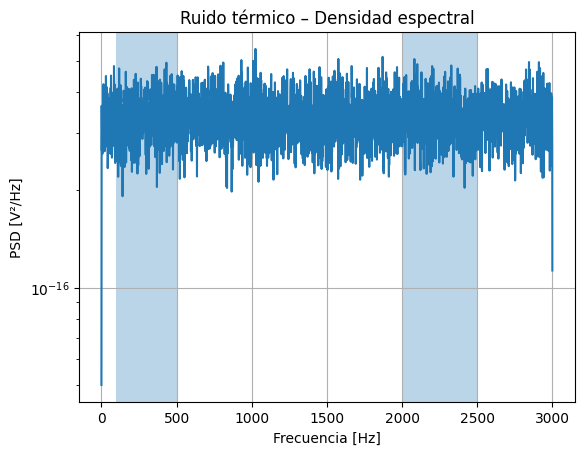

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ruido térmico es estacionario
# La PSD es independiente de la frecuencia
# Medir en distintas bandas da el mismo resultado



# -------------------------
# Parámetros
# -------------------------
fs = 6000              # Frecuencia de muestreo (Hz)
N = 200000             # Número de muestras
sigma = 1e-6           # RMS del ruido (1 µV)

# -------------------------
# Ruido térmico (blanco)
# -------------------------
noise = sigma * np.random.randn(N)

# -------------------------
# Densidad espectral (Welch)
# -------------------------
f, psd = welch(
    noise,
    fs=fs,
    window='hann',
    nperseg=8192,
    scaling='density'
)

# -------------------------
# Definir dos bandas arbitrarias
# -------------------------
band1 = (100, 500)      # Hz
band2 = (2000, 2500)   # Hz

# Índices de cada banda
idx1 = (f >= band1[0]) & (f <= band1[1])
idx2 = (f >= band2[0]) & (f <= band2[1])

# Densidad promedio en cada banda
psd_band1 = np.mean(psd[idx1])
psd_band2 = np.mean(psd[idx2])

# Convertir a dBV^2/Hz
psd_band1_db = 10 * np.log10(psd_band1)
psd_band2_db = 10 * np.log10(psd_band2)

# -------------------------
# Resultados numéricos
# -------------------------
print("Densidad espectral promedio:")
print(f"Banda {band1[0]}–{band1[1]} Hz: {psd_band1:.3e} V²/Hz ({psd_band1_db:.2f} dBV²/Hz)")
print(f"Banda {band2[0]}–{band2[1]} Hz: {psd_band2:.3e} V²/Hz ({psd_band2_db:.2f} dBV²/Hz)")

# -------------------------
# Gráfico
# -------------------------
plt.figure()
plt.semilogy(f, psd)
plt.axvspan(*band1, alpha=0.3)
plt.axvspan(*band2, alpha=0.3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.title("Ruido térmico – Densidad espectral")
plt.grid(True)
plt.show()
